# Эксперимент 01: SVM на MFCC

**Краткое описание модели:** MFCC-статистики + признаки букв -> SVM с RBF-ядром и подбором гиперпараметров через GridSearchCV.

In [1]:
import sys
from pathlib import Path
import numpy as np
import time
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    classification_report,
)
import matplotlib.pyplot as plt
import pandas as pd

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent))

from shared import config, data_utils
from shared.results_utils import save_result_csv

## 1. Загрузка разбиений и извлечение признаков

In [2]:
paths_train, paths_val, paths_test, y_train, y_val, y_test, letters_train, letters_val, letters_test = data_utils.get_splits()
print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")
print(f"Train: good={np.sum(y_train==0)}, bad={np.sum(y_train==1)}")
n_letters = letters_train.shape[1]

Train: 1942, Val: 417, Test: 417
Train: good=1311, bad=631


In [3]:
def extract(path):
    return data_utils.extract_mfcc_stats(path)

X_train = data_utils.build_feature_matrix(paths_train, extract, n_jobs=-1)
X_val   = data_utils.build_feature_matrix(paths_val,   extract, n_jobs=-1)
X_test  = data_utils.build_feature_matrix(paths_test,  extract, n_jobs=-1)

X_train = np.hstack([X_train, letters_train])
X_val   = np.hstack([X_val, letters_val])
X_test  = np.hstack([X_test, letters_test])

print(f"Признаков на объект: {X_train.shape[1]}")

Признаков на объект: 88


## 2. Подбор гиперпараметров и обучение

In [4]:
# Взвешивание классов из-за дисбаланса
classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", class_weight=class_weight, random_state=config.RANDOM_STATE)),
])

param_grid = {
    "clf__C": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0],
    "clf__gamma": ["scale", "auto", 0.001, 0.01, 0.05, 0.1, 0.5],
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="f1_macro",
    refit=True,
    n_jobs=-1,
    verbose=1,
)
t0 = time.perf_counter()
grid.fit(X_train, y_train)
train_time_sec = time.perf_counter() - t0

print("Лучшие гиперпараметры (по F1-macro на CV):", grid.best_params_)
print("Лучший F1-macro (CV):", f"{grid.best_score_:.4f}")

clf = grid.best_estimator_

Fitting 5 folds for each of 49 candidates, totalling 245 fits
Лучшие гиперпараметры (по F1-macro на CV): {'clf__C': 1.0, 'clf__gamma': 'scale'}
Лучший F1-macro (CV): 0.6708


### Графики: зависимость F1-macro (CV) от гиперпараметров

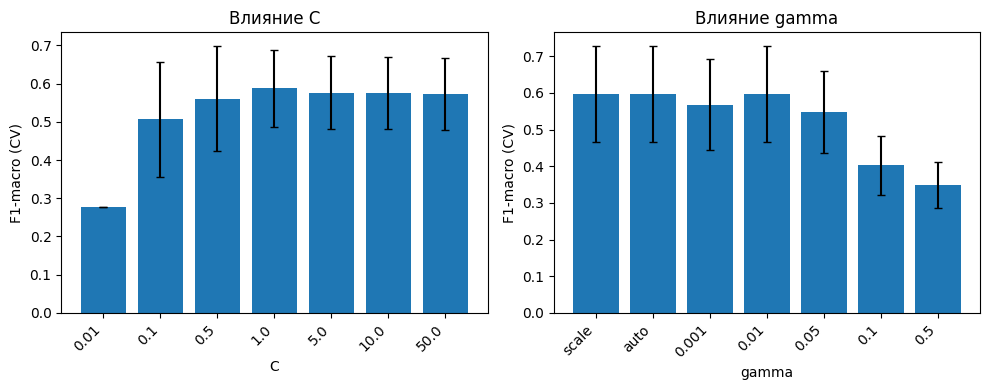

In [5]:
cv_results = grid.cv_results_
param_names = list(param_grid.keys())

fig, axes = plt.subplots(1, len(param_names), figsize=(5 * len(param_names), 4))
if len(param_names) == 1:
    axes = [axes]
for ax, pname in zip(axes, param_names):
    key = "param_" + pname
    vals = list(param_grid[pname])
    scores_mean = []
    scores_std = []
    for v in vals:
        mask = cv_results[key] == v
        scores_mean.append(np.mean(cv_results["mean_test_score"][mask]))
        s = np.std(cv_results["mean_test_score"][mask])
        scores_std.append(s if not np.isnan(s) else 0.0)
    x = np.arange(len(vals))
    ax.bar(x, scores_mean, yerr=scores_std, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in vals], rotation=45, ha="right")
    ax.set_xlabel(pname.replace("clf__", ""))
    ax.set_ylabel("F1-macro (CV)")
    ax.set_title(f"Влияние {pname.replace('clf__', '')}")
plt.tight_layout()
plt.show()

## 3. Оценка на тесте и метрики

In [6]:
y_pred = clf.predict(X_test)
y_proba = clf.decision_function(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_bad   = f1_score(y_test, y_pred, pos_label=config.CLASS_BAD)
roc_auc  = roc_auc_score(y_test, y_proba)
precision_bad = precision_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)
recall_bad    = recall_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)

print(classification_report(y_test, y_pred, target_names=config.CLASS_NAMES))
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 macro: {f1_macro:.4f}")
print(f"F1 (bad): {f1_bad:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")
print(f"Precision (bad): {precision_bad:.4f}")
print(f"Recall (bad):    {recall_bad:.4f}")

metrics_table = pd.DataFrame([{
    "accuracy": accuracy, "f1_macro": f1_macro, "f1_bad": f1_bad,
    "roc_auc": roc_auc, "precision_bad": precision_bad, "recall_bad": recall_bad,
}])
print("\nТаблица метрик (тест):")
display(metrics_table)

              precision    recall  f1-score   support

        good       0.80      0.74      0.77       282
         bad       0.53      0.61      0.57       135

    accuracy                           0.70       417
   macro avg       0.66      0.68      0.67       417
weighted avg       0.71      0.70      0.70       417

Accuracy: 0.6978
F1 macro: 0.6680
F1 (bad): 0.5685
ROC-AUC:  0.7522
Precision (bad): 0.5287
Recall (bad):    0.6148

Таблица метрик (тест):


,accuracy,f1_macro,f1_bad,roc_auc,precision_bad,recall_bad
0,0.697842,0.66801,0.568493,0.752167,0.528662,0.614815


## 4. Запись метрик в файл

In [7]:
save_result_csv(
    exp_dir=exp_dir,
    experiment_id="exp_01_mfcc_svm",
    experiment_name="SVM на MFCC",
    model="SVM (RBF)",
    accuracy=accuracy,
    f1_macro=f1_macro,
    f1_bad=f1_bad,
    roc_auc=roc_auc,
    precision_bad=precision_bad,
    recall_bad=recall_bad,
    notes="n_mfcc=20, GridSearchCV " + str(grid.best_params_),
    num_params=None,
    train_time_sec=train_time_sec,
)

PosixPath('/mnt/d/Projects/HSE/VKR/VKR/experiments/exp_01_mfcc_svm/result.csv')